# NOE (Liovillie space and Lindblad)
## Author: Vineeth Francis Thalakottoor, vineeth.thalakottoor@cea.fr
- Nuclear Overhauser effect 
- In Liovillie Space
- Lindblad Master equation

In [16]:
# Define the source path
SourcePath = '/home/vineeth/Documents/PyOR/PyOR/Source_Doc'

# Add source path
import sys
sys.path.append(SourcePath)
import time
%matplotlib ipympl

# Import PyOR package
from PyOR_QuantumSystem import QuantumSystem as QunS
from PyOR_Hamiltonian import Hamiltonian
from PyOR_DensityMatrix import DensityMatrix
from PyOR_QuantumObject import QunObj
from PyOR_HardPulse import HardPulse
from PyOR_Basis import Basis
from PyOR_Evolution import Evolutions
from PyOR_Plotting import Plotting
import PyOR_SignalProcessing as Spro
from PyOR_Commutators import Commutators
from PyOR_QuantumLibrary import QuantumLibrary
from PyOR_Relaxation import RelaxationProcess
from PyOR_QuantumLibrary import QuantumLibrary
QLib = QuantumLibrary()

In [17]:
# Define the spin system
Spin_list = {"A" : "H1", "B" : "H1"}
QS = QunS(Spin_list,PrintDefault=False)

Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am
For particle B: Bx, By, Bz, Bp, Bm

To see the matrix form use the attribute .matrix


### Set parameters

In [18]:
# New way
QS.Configure(
    # System
    PropagationSpace="Liouville",
    MasterEquation="Lindblad",

    # Field
    B0=9.4,
    OFFSET={"A": 10.0, "B": 50.0},

    # Coupling
    Jcouplings=[("A", "B", 5.0)],
    Dipole_Pairs=[("A", "B")],

    # Temperature
    I_spintemp={"A": 300.0, "B": 300.0},
    F_spintemp={"A": 300.0, "B": 300.0},
    Lindblad_Temp=300.0,

    # Relaxation
    Rprocess="Auto-correlated Dipolar Homonuclear",
    RelaxParDipole_tau=10.0e-12,
    RelaxParDipole_bIS=[30.0e3],
)

Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am
For particle B: Bx, By, Bz, Bp, Bm

To see the matrix form use the attribute .matrix

Setting derived parameters from dictionaries
-------------------------------------------
OmegaRF   <- OMEGA_RF  : [-2514706800.0, -2514706800.0] from {'A': -2514706800.0, 'B': -2514706800.0}
Offset    <- OFFSET    : [10.0, 50.0] from {'A': 10.0, 'B': 50.0}
Ispintemp <- I_spintemp: [300.0, 300.0] from {'A': 300.0, 'B': 300.0}
Fspintemp <- F_spintemp: [300.0, 300.0] from {'A': 300.0, 'B': 300.0}
RDxi      <- RD_xi     : [0, 0] from {'A': 0, 'B': 0}
RDphase   <- RD_phase  : [0, 0] from {'A': 0, 'B': 0}
-------------------------------------------
Larmor Frequency in MHz:  [-400.22802765 -400.22806765]


### Generate Hamiltonians

In [19]:
# generate Larmor Frequencies
QS.print_Larmor = True
Ham = Hamiltonian(QS)
COMM = Commutators()
Hz = Ham.Zeeman_RotFrame()

# J coupling Hamiltonian
Hj = Ham.Jcoupling()

# Generating the commutation superoperator

QS.RowColOrder = 'C'
QLib = QuantumLibrary(QS)

Hz_L = QLib.CommutationSuperoperator(Hz+Hj)

Larmor Frequency in MHz:  [-400.22802765 -400.22806765]


### product operator basis (Shift Z or PMZ basis)

In [20]:
BS = Basis(QS)

sort = 'negative to positive'
Index = False
Normal = True
Basis_PMZ, coh_PMZ, dic_PMZ = BS.ProductOperators_SpinHalf_PMZ(sort,Index,Normal)

### Initialize Density Matrix

In [21]:
DM = DensityMatrix(QS,Ham)

Thermal_DensMatrix = True

if Thermal_DensMatrix:    
    # High Temperature
    HT_approx = True
    
    # Initial Density Matrix
    rho_in_L = DM.EquilibriumDensityMatrix(QS.Ispintemp,HT_approx)
    
    # Equlibrium Density Matrix
    rhoeq_L = DM.EquilibriumDensityMatrix(QS.Fspintemp,HT_approx)
else:
    rho_in = QS.Az + QS.Bz
    rhoeq = QS.Az + QS.Bz   

Trace of density matrix =  1.0
Trace of density matrix =  1.0


In [22]:
DM.DensityMatrix_Components(rho_in_L,Basis_PMZ,dic_PMZ)

Density Matrix = 2e-05 Iz1 Id2  + 2e-05 Id1 Iz2  + 0.5 Id1 Id2 


### Pulse

In [23]:
HardP = HardPulse(QS)

flip_angle1 = 0.0   # Flip angle Spin 1
flip_angle2 = 180.0 # Flip angle Spin 2

rho = HardP.Rotate_Pulse(rho_in_L,flip_angle1,QS.Ay)
rho = HardP.Rotate_Pulse(rho,flip_angle2,QS.By)

In [24]:
DM.DensityMatrix_Components(rho,Basis_PMZ,dic_PMZ)

Density Matrix = 2e-05 Iz1 Id2  + -2e-05 Id1 Iz2  + 0.5 Id1 Id2 


## Evolution 

In [25]:
QS.AcqDT = 0.0001
QS.AcqAQ = 30.0
QS.OdeMethod = 'DOP853'
QS.PropagationMethod = "Relaxation Lindblad"

# Relaxation Superoperator
RPro = RelaxationProcess(QS)
R_L = RPro.Relaxation()

EVol = Evolutions(QS,Ham)

start_time = time.time()
t, rho_t = EVol.Evolution(rho,rhoeq_L,Hz_L,R_L)
end_time = time.time()
timetaken = end_time - start_time
print("Total time = %s seconds " % (timetaken))

Larmor Frequency in MHz:  [-400.22802765 -400.22806765]
Larmor Frequency in MHz:  [-400.22802765 -400.22806765]
Total time = 1.1049938201904297 seconds 


In [26]:
R_L.matrix

Matrix([
[  0.159576453803091,                  0,                  0,                 0,                  0, -0.0266319436050379, -0.0266319436050379,                  0,                  0, -0.0266319436050379, -0.0266319436050379,                  0,                 0,                  0,                  0,  -0.106329591705398],
[                  0,  0.150832537765222, 0.0621616669026959,                 0,                  0,                   0,                   0, 0.0266319436050379,                  0,                   0,                   0, 0.0266319436050379,                 0,                  0,                  0,                   0],
[                  0, 0.0621616669026959,  0.150832537765222,                 0,                  0,                   0,                   0, 0.0266319436050379,                  0,                   0,                   0, 0.0266319436050379,                 0,                  0,                  0,                   0],
[            

### Expectation Value

In [27]:
det_Z1 = QS.Az
det_Z2 = QS.Bz

t, signal_Z1 = EVol.Expectation(rho_t,det_Z1)
t, signal_Z2 = EVol.Expectation(rho_t,det_Z2)

In [28]:
MoA = rho_in_L.Expectation(QS.Az)
MoB = rho_in_L.Expectation(QS.Bz)

## Plotting

In [29]:
plot = Plotting(QS)

/home/vineeth/Documents/PyOR/PyOR/Source_Doc/PyOR_Plotting.py:544: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  fig = plt.figure(self.fig_counter, constrained_layout=True, figsize=self.PlotFigureSize)


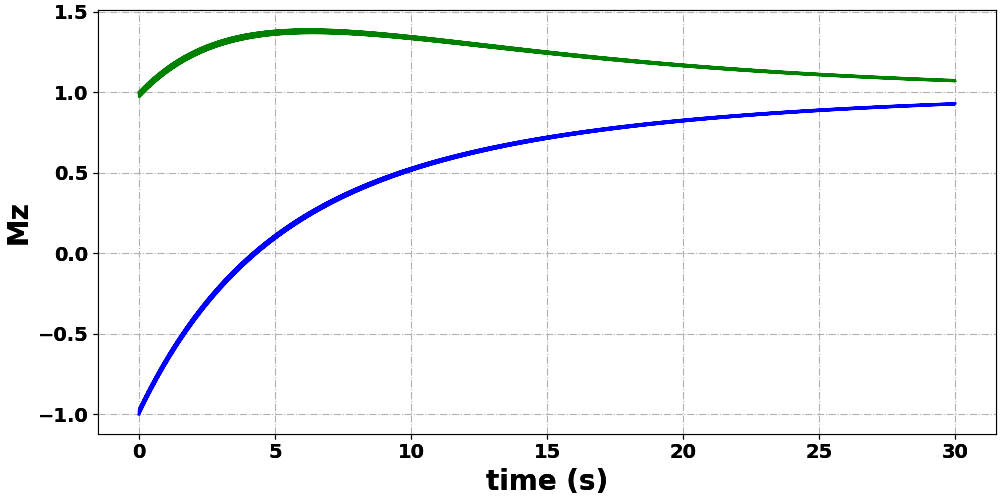

In [30]:
plot.PlotFigureSize = (10,5)
plot.PlotFontSize = 20
plot.PlottingMulti([t,t],[signal_Z1/MoA,signal_Z2/MoB],"time (s)","Mz",["green","blue"])